# Summarized Dataset Goals:
 summarized statistics (means/stds/avgs/min/max/variance in kinematics/kinetics) for the session with the biomechanics + EMG data (better for tree based models to test that route for injury classification.)

 Reasons:
    - variance in kinematcis/kinetics is the step toward the Josh Hejka project where we are seeing days where players are exaggerating or overcompensating (higher variance in technique/force from typical motion)

metrics to add:
    - variance in kinematics/kinetics ongoing AND variance of them from the typical form OR optimal form 
        - possibly find optimal form through bayesian optimization for success (success being low injury_risk + High velo)



In [7]:
import pandas as pd
import mysql.connector
from sqlalchemy import create_engine
import logging
from datetime import datetime, timedelta
import numpy as np

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def get_database_connection():
    """Create and return a database connection."""
    return mysql.connector.connect(
        host="10.200.200.107",
        user="scriptuser",
        password="!!Driveline11",
        database="theia_pitching_db"
    )

def check_data_completeness(df, table_name, key_columns):
    """
    Check for missing/incomplete data in a given DataFrame.
    Logs the sum of nulls per column, unique non-null counts, and data types.
    If a 'time' column is present, calculates basic time gap statistics.
    """
    logger.info(f"\nChecking data completeness for {table_name}:")
    
    # Count null values per column
    null_counts = df.isnull().sum()
    if null_counts.any():
        logger.warning(f"Null values found in {table_name}:")
        logger.warning(null_counts[null_counts > 0])
    else:
        logger.info("No null values found.")
    
    # Report unique non-null counts and column types
    for col in df.columns:
        unique_count = df[col].nunique(dropna=True)
        col_type = df[col].dtype
        logger.info(f"Column '{col}': Type = {col_type}, Unique non-null values = {unique_count}")
    
    # If a 'time' column exists, provide basic statistics on time gaps grouped by session_trial.
    if 'time' in df.columns:
        time_stats = df.groupby('session_trial')['time'].apply(lambda x: x.diff().describe())
        logger.info(f"Time series statistics for {table_name} (averaged across sessions):\n{time_stats.mean()}")

def validate_join(df_before, df_after, join_type, key_columns):
    """
    Validate that an inner join did not lose rows or key information.
    Logs row counts, unique session_trial counts, and warns if any key columns' unique counts differ.
    """
    logger.info(f"\nValidating {join_type} join:")
    
    before_counts = {
        'rows': len(df_before),
        'session_trials': df_before['session_trial'].nunique(),
        'times': df_before['time'].nunique() if 'time' in df_before.columns else None
    }
    after_counts = {
        'rows': len(df_after),
        'session_trials': df_after['session_trial'].nunique(),
        'times': df_after['time'].nunique() if 'time' in df_after.columns else None
    }
    
    logger.info(f"Rows before: {before_counts['rows']}, after: {after_counts['rows']}")
    logger.info(f"Unique trials before: {before_counts['session_trials']}, after: {after_counts['session_trials']}")
    
    # Check if any trials were lost in the join
    if 'session_trial' in df_before.columns:
        lost_trials = set(df_before['session_trial'].unique()) - set(df_after['session_trial'].unique())
        if lost_trials:
            logger.warning(f"Lost trials in {join_type} join: {lost_trials}")
    
    # Compare unique counts for each key column
    for col in key_columns:
        if col in df_before.columns and col in df_after.columns:
            before_unique = df_before[col].nunique()
            after_unique = df_after[col].nunique()
            if before_unique != after_unique:
                logger.warning(f"Unique count for '{col}' changed: {before_unique} -> {after_unique}")
    
    return before_counts['rows'] == after_counts['rows']

def integrate_joint_data():
    """
    Loads and validates joint angles, forces, moments, and velocities for sessions.
    Joins the datasets stepwise with validations and then merges in trial and session metadata.
    
    Note: This integration currently uses a last-month filter for sessions.
    """
    conn = get_database_connection()
    
    # Define a time filter for sessions (last month)
    one_month_ago = (datetime.now() - timedelta(days=30)).strftime('%Y-%m-%d')
    
    logger.info("Loading sessions from the last month...")
    sessions = pd.read_sql(f"""
        SELECT 
            session,
            date,
            level,
            lab,
            height_meters,
            mass_kilograms
        FROM `sessions`
        WHERE date >= '{one_month_ago}'
    """, conn)
    
    logger.info("Loading trials for these sessions...")
    sessions_list = sessions['session'].tolist()
    trials = pd.read_sql(f"""
        SELECT 
            session_trial,
            session,
            trial,
            pitch_type,
            handedness,
            filename
        FROM `trials`
        WHERE session IN ({','.join(map(str, sessions_list))})
    """, conn)
    
    valid_session_trials = tuple(trials['session_trial'].unique())
    
    logger.info("Loading joint data tables...")
    joint_angles = pd.read_sql(f"""
        SELECT * FROM `joint_angles`
        WHERE session_trial IN {valid_session_trials}
    """, conn)
    
    joint_forces = pd.read_sql(f"""
        SELECT * FROM `joint_forces`
        WHERE session_trial IN {valid_session_trials}
    """, conn)
    
    joint_moments = pd.read_sql(f"""
        SELECT * FROM `joint_moments`
        WHERE session_trial IN {valid_session_trials}
    """, conn)
    
    joint_velos = pd.read_sql(f"""
        SELECT * FROM `joint_velos`
        WHERE session_trial IN {valid_session_trials}
    """, conn)
    
    # Validate completeness of each base table
    key_columns = ['session_trial', 'time']
    check_data_completeness(joint_angles, 'joint_angles', key_columns)
    check_data_completeness(joint_forces, 'joint_forces', key_columns)
    check_data_completeness(joint_moments, 'joint_moments', key_columns)
    check_data_completeness(joint_velos, 'joint_velos', key_columns)
    
    # Perform inner joins with validation at each step.
    logger.info("Joining joint_angles and joint_forces...")
    angles_forces = pd.merge(
        joint_angles,
        joint_forces,
        on=['session_trial', 'time'],
        how='inner'
    )
    validate_join(joint_angles, angles_forces, "angles-forces", key_columns)
    
    logger.info("Adding joint_moments to the join...")
    angles_forces_moments = pd.merge(
        angles_forces,
        joint_moments,
        on=['session_trial', 'time'],
        how='inner'
    )
    validate_join(angles_forces, angles_forces_moments, "moments", key_columns)
    
    logger.info("Adding joint_velos to the join...")
    all_joint_data = pd.merge(
        angles_forces_moments,
        joint_velos,
        on=['session_trial', 'time'],
        how='inner'
    )
    validate_join(angles_forces_moments, all_joint_data, "velocities", key_columns)
    
    logger.info("Merging with trials metadata...")
    joint_with_trials = pd.merge(
        all_joint_data,
        trials,
        on='session_trial',
        how='left'
    )
    validate_join(all_joint_data, joint_with_trials, "trials", key_columns + ['session', 'trial', 'pitch_type'])
    
    logger.info("Merging with sessions metadata...")
    final_dataset = pd.merge(
        joint_with_trials,
        sessions,
        on='session',
        how='left'
    )
    validate_join(joint_with_trials, final_dataset, "sessions", key_columns + ['session', 'date', 'level'])
    
    logger.info("\nFinal Integrated Dataset Summary:")
    logger.info(f"Total rows: {len(final_dataset)}")
    logger.info(f"Unique trials: {final_dataset['session_trial'].nunique()}")
    logger.info(f"Unique sessions: {final_dataset['session'].nunique()}")
    logger.info(f"Date range: {final_dataset['date'].min()} to {final_dataset['date'].max()}")
    
    # Check for missing data in critical columns
    critical_columns = ['session_trial', 'time', 'session', 'date', 'pitch_type']
    missing_data = final_dataset[critical_columns].isnull().sum()
    if missing_data.any():
        logger.warning("Missing data in critical columns:")
        logger.warning(missing_data[missing_data > 0])
    
    conn.close()
    return final_dataset

def run_final_query(filter_type='LAST_DAY', specific_date=None, specific_month=None):
    """
    Executes the final comprehensive query which uses several CTEs to combine biomechanical
    data (with phase segmentation, energy, loads, kinematics, and composite injury scores)
    into a single result set.

    The query now uses a single, dynamic date filter applied in the 'date_filtered_sessions' CTE.
    
    Additionally, the final metrics now include the session date and trial time for 
    chronological and sequential analysis.

    Parameters:
      filter_type (str): One of 'LAST_DAY', 'LAST_5_DAYS', 'LAST_MONTH', 'SPECIFIC_DATE', 'SPECIFIC_MONTH'
      specific_date (str): Date in 'YYYY-MM-DD' format (required for 'SPECIFIC_DATE')
      specific_month (str): Month in 'YYYY-MM' format (required for 'SPECIFIC_MONTH')
      
    Returns:
      A pandas DataFrame with the final summarized biomechanical metrics.
    """
    conn = get_database_connection()
    
    # Build the dynamic filter condition for date_filtered_sessions
    if filter_type == 'LAST_DAY':
        date_filter_condition = "s.date = (SELECT MAX(date) FROM `sessions`)"
    elif filter_type == 'LAST_5_DAYS':
        date_filter_condition = "s.date >= DATE_SUB((SELECT MAX(date) FROM `sessions`), INTERVAL 4 DAY)"
    elif filter_type == 'LAST_MONTH':
        date_filter_condition = "s.date >= DATE_SUB((SELECT MAX(date) FROM `sessions`), INTERVAL 30 DAY)"
    elif filter_type == 'SPECIFIC_DATE':
        if not specific_date:
            raise ValueError("specific_date is required for SPECIFIC_DATE filter_type")
        date_filter_condition = f"s.date = '{specific_date}'"
    elif filter_type == 'SPECIFIC_MONTH':
        if not specific_month:
            raise ValueError("specific_month is required for SPECIFIC_MONTH filter_type")
        date_filter_condition = f"DATE_FORMAT(s.date, '%Y-%m') = '{specific_month}'"
    else:
        raise ValueError(f"Invalid filter_type: {filter_type}")
    
    # Build the final query with the dynamic filter in the date_filtered_sessions CTE.
    # --- CHANGES BEGIN ---
    # 1. Added t.time AS trial_time to the date_filtered_sessions CTE.
    # 2. In the final_metrics CTE, added dfs.date (as session_date) and dfs.trial_time (as trial_time) to SELECT and GROUP BY.
    # 3. Updated ORDER BY clause to sort by session_date and trial_time first.
    final_query = f"""
    /*
    ================================================================================
    -- Comprehensive Biomechanical Metrics Query
    ================================================================================
    */
    
    WITH date_filtered_sessions AS (
        SELECT
            t.session_trial,
            t.pitch_type,         -- Pitch type from trials
            t.ball_weight,        -- Ball weight from trials
            t.session_type,       -- Session type from trials
            t.handedness,         -- Pitcher handedness from trials
            s.date,
            t.time AS trial_time,  -- Added: trial time from trials
            s.session,
            s.height_meters,      -- Player height from sessions
            s.mass_kilograms,     -- Player mass from sessions
            s.level,              -- Player level from sessions
            s.lab,                -- Facility/lab info from sessions
            u.name AS player_name,  -- Player name from users table
            u.traq AS player_id     -- Player ID from users table
        FROM `trials` t
        JOIN `sessions` s ON t.session = s.session
        JOIN `users` u ON s.user = u.user
        WHERE {date_filter_condition}
    ),
    
    pitch_phases AS (
        SELECT 
            e.session_trial,
            e.PKH_time AS phase_pkh,
            e.FP_v5_time AS phase_fp,
            e.MER_time AS phase_mer,
            e.BR_time AS phase_br,
            e.MAD_time AS phase_mad,
            (e.FP_v5_time - e.PKH_time) AS duration_pkh_to_fp,
            (e.MER_time - e.FP_v5_time) AS duration_fp_to_mer,
            (e.BR_time - e.MER_time) AS duration_mer_to_br,
            (e.MAD_time - e.BR_time) AS duration_br_to_mad
        FROM `events` e
        INNER JOIN date_filtered_sessions dfs ON e.session_trial = dfs.session_trial
    ),
    
    energy_metrics AS (
        SELECT 
            session_trial,
            time,
            shoulder_energy_transfer,
            shoulder_energy_generation,
            elbow_energy_transfer,
            elbow_energy_generation,
            lead_ankle_energy_transfer,
            lead_ankle_energy_generation,
            rear_ankle_energy_transfer,
            rear_ankle_energy_generation,
            lead_knee_energy_transfer,
            lead_knee_energy_generation,
            rear_knee_energy_transfer,
            rear_knee_energy_generation,
            lead_hip_energy_transfer,
            lead_hip_energy_generation,
            rear_hip_energy_transfer,
            rear_hip_energy_generation
        FROM `energetics`
    ),
    
    force_data AS (
        SELECT
            session_trial,
            time,
            lead_force_x,
            lead_force_y,
            lead_force_z,
            lead_force_mag,
            rear_force_x,
            rear_force_y,
            rear_force_z,
            rear_force_mag
        FROM `force_plates`
    ),
    
    joint_loads AS (
        SELECT
            jf.session_trial,
            jf.time,
            jf.elbow_force_x,
            jf.elbow_force_y,
            jf.elbow_force_z,
            jf.shoulder_upper_arm_force_x,
            jf.shoulder_upper_arm_force_y,
            jf.shoulder_upper_arm_force_z,
            jm.elbow_moment_x,
            jm.elbow_moment_y,
            jm.elbow_moment_z,
            jm.shoulder_thorax_moment_x,
            jm.shoulder_thorax_moment_y,
            jm.shoulder_thorax_moment_z
        FROM `joint_forces` jf
        JOIN `joint_moments` jm 
          ON jf.session_trial = jm.session_trial 
         AND jf.time = jm.time
    ),
    
    biomech_with_phase AS (
        SELECT 
            ja.session_trial,
            ja.time,
            ja.shoulder_angle_x,
            ja.shoulder_angle_y,
            ja.shoulder_angle_z,
            ja.elbow_angle_x,
            ja.elbow_angle_y,
            ja.elbow_angle_z,
            jv.shoulder_velo_x,
            jv.shoulder_velo_y,
            jv.shoulder_velo_z,
            jv.elbow_velo_x,
            jv.elbow_velo_y,
            jv.elbow_velo_z,
            ja.torso_angle_x,
            ja.torso_angle_y,
            ja.torso_angle_z,
            ja.pelvis_angle_x,
            ja.pelvis_angle_y,
            ja.pelvis_angle_z,
            jv.torso_velo_x,
            jv.torso_velo_y,
            jv.torso_velo_z,
            em.shoulder_energy_transfer,
            em.shoulder_energy_generation,
            em.elbow_energy_transfer,
            em.elbow_energy_generation,
            em.lead_ankle_energy_transfer,
            em.lead_ankle_energy_generation,
            em.rear_ankle_energy_transfer,
            em.rear_ankle_energy_generation,
            em.lead_knee_energy_transfer,
            em.lead_knee_energy_generation,
            em.rear_knee_energy_transfer,
            em.rear_knee_energy_generation,
            em.lead_hip_energy_transfer,
            em.lead_hip_energy_generation,
            em.rear_hip_energy_transfer,
            em.rear_hip_energy_generation,
            jl.elbow_force_x,
            jl.elbow_force_y,
            jl.elbow_force_z,
            jl.shoulder_upper_arm_force_x,
            jl.shoulder_upper_arm_force_y,
            jl.shoulder_upper_arm_force_z,
            jl.elbow_moment_x,
            jl.elbow_moment_y,
            jl.elbow_moment_z,
            jl.shoulder_thorax_moment_x,
            jl.shoulder_thorax_moment_y,
            jl.shoulder_thorax_moment_z,
            fd.lead_force_mag,
            fd.rear_force_mag,
            ABS(ja.torso_angle_z - ja.pelvis_angle_z) AS trunk_pelvis_dissociation,
            CASE 
                WHEN ja.time <= pp.phase_pkh THEN 'Wind-Up'
                WHEN ja.time <= pp.phase_fp THEN 'Stride'
                WHEN ja.time <= pp.phase_mer THEN 'Arm Cocking'
                WHEN ja.time <= pp.phase_br THEN 'Arm Acceleration'
                WHEN ja.time <= pp.phase_mad THEN 'Arm Deceleration'
                ELSE 'Follow Through'
            END AS pitch_phase,
            pp.duration_pkh_to_fp,
            pp.duration_fp_to_mer,
            pp.duration_mer_to_br,
            pp.duration_br_to_mad
        FROM `joint_angles` ja
        JOIN pitch_phases pp 
          ON ja.session_trial = pp.session_trial
        JOIN `joint_velos` jv 
          ON ja.session_trial = jv.session_trial 
         AND ja.time = jv.time
        LEFT JOIN energy_metrics em 
          ON ja.session_trial = em.session_trial 
         AND ja.time = em.time
        LEFT JOIN joint_loads jl 
          ON ja.session_trial = jl.session_trial 
         AND ja.time = jl.time
        LEFT JOIN force_data fd 
          ON ja.session_trial = fd.session_trial 
         AND ja.time = fd.time
    ),
    
    final_metrics AS (
        SELECT 
            bp.session_trial,
            dfs.player_name,
            dfs.player_id,
            dfs.date AS session_date,      -- Added: session date from sessions
            dfs.trial_time AS trial_time,    -- Added: trial time from trials
            dfs.height_meters,
            dfs.mass_kilograms,
            dfs.level,
            dfs.lab,
            dfs.pitch_type,
            dfs.ball_weight,
            dfs.session_type,
            dfs.handedness,
            bp.pitch_phase,
            COUNT(*) AS frames_in_phase,
            AVG(shoulder_angle_x) AS avg_shoulder_flex_ext,
            AVG(shoulder_angle_y) AS avg_shoulder_abd_add,
            AVG(shoulder_angle_z) AS avg_shoulder_rotation,
            AVG(elbow_angle_x) AS avg_elbow_flex_ext,
            MAX(ABS(shoulder_velo_z)) AS max_shoulder_rotation_speed,
            MAX(ABS(elbow_velo_x)) AS max_elbow_extension_speed,
            AVG(torso_angle_x) AS avg_torso_flex,
            AVG(torso_angle_y) AS avg_torso_lateral_tilt,
            MAX(ABS(torso_velo_z)) AS max_torso_rotation_speed,
            AVG(shoulder_energy_transfer) AS avg_shoulder_energy_transfer,
            MAX(shoulder_energy_generation) AS max_shoulder_energy_generation,
            AVG(elbow_energy_transfer) AS avg_elbow_energy_transfer,
            MAX(elbow_energy_generation) AS max_elbow_energy_generation,
            MAX(ABS(elbow_moment_y)) AS max_elbow_varus_moment,
            MAX(ABS(shoulder_thorax_moment_x)) AS max_shoulder_distraction_force,
            MAX(lead_force_mag) AS max_lead_leg_force,
            MAX(rear_force_mag) AS max_push_off_force,
            SUM(lead_force_mag) AS cumulative_lead_force,
            STDDEV(shoulder_angle_z) AS shoulder_rotation_variability,
            AVG(trunk_pelvis_dissociation) AS avg_trunk_pelvis_dissociation,
            AVG(duration_pkh_to_fp) AS avg_duration_pkh_to_fp,
            AVG(duration_fp_to_mer) AS avg_duration_fp_to_mer,
            AVG(duration_mer_to_br) AS avg_duration_mer_to_br,
            AVG(duration_br_to_mad) AS avg_duration_br_to_mad,
            p.pitch_speed_mph,
            p.max_shoulder_internal_rotational_velo,
            STDDEV(elbow_angle_x) AS elbow_flexion_variability,
            STDDEV(torso_angle_z) AS torso_rotation_variability,
            STDDEV(pelvis_angle_z) AS pelvis_rotation_variability,
            STDDEV(elbow_moment_y) AS elbow_varus_moment_variability,
            STDDEV(shoulder_thorax_moment_z) AS shoulder_rotation_moment_variability,
            STDDEV(shoulder_velo_z) AS shoulder_rotation_velocity_variability,
            STDDEV(elbow_velo_x) AS elbow_extension_velocity_variability,
            STDDEV(torso_velo_z) AS torso_rotation_velocity_variability,
            STDDEV(shoulder_energy_transfer) AS shoulder_energy_transfer_variability,
            STDDEV(elbow_energy_transfer) AS elbow_energy_transfer_variability,
            STDDEV(lead_force_mag) AS lead_force_variability,
            STDDEV(rear_force_mag) AS rear_force_variability,
            STDDEV(trunk_pelvis_dissociation) AS trunk_pelvis_dissociation_variability
        FROM biomech_with_phase bp
        JOIN date_filtered_sessions dfs ON bp.session_trial = dfs.session_trial
        LEFT JOIN poi p ON bp.session_trial = p.session_trial
        GROUP BY 
            bp.session_trial, 
            bp.pitch_phase,
            dfs.player_name,
            dfs.player_id,
            dfs.date,                -- Added to GROUP BY: session date
            dfs.trial_time,          -- Added to GROUP BY: trial time
            dfs.height_meters,
            dfs.mass_kilograms,
            dfs.level,
            dfs.lab,
            dfs.pitch_type,
            dfs.ball_weight,
            dfs.session_type,
            dfs.handedness
    )
    
    SELECT * FROM final_metrics
    ORDER BY 
        session_date,          -- Order by session date first
        trial_time,            -- Then order by trial time
        CASE pitch_phase
            WHEN 'Wind-Up' THEN 1
            WHEN 'Stride' THEN 2
            WHEN 'Arm Cocking' THEN 3
            WHEN 'Arm Acceleration' THEN 4
            WHEN 'Arm Deceleration' THEN 5
            WHEN 'Follow Through' THEN 6
        END;
    """
    # --- CHANGES END ---
    
    logger.info(f"Executing final SQL query with filter_type: {filter_type}")
    final_result = pd.read_sql(final_query, conn)
    conn.close()
    return final_result


def check_summary_dataset(df, dataset_name="Final Summarized Dataset"):
    """
    Perform quality checks on the summarized dataset.
    Logs the sum and percentage of null values for each column along with basic statistics.
    This function helps determine what preprocessing might be needed before applying machine learning.
    """
    logger.info(f"\nChecking {dataset_name} completeness:")
    total_rows = len(df)
    logger.info(f"Total rows: {total_rows}")
    
    # Calculate missing values per column
    missing_counts = df.isnull().sum()
    missing_percentage = (missing_counts / total_rows) * 100
    
    # Create a summary DataFrame with missing counts, percentage, and data types.
    # Convert the data types to strings so they can be saved correctly.
    summary = pd.DataFrame({
        "Missing Count": missing_counts,
        "Missing Percentage": missing_percentage,
        "Data Type": df.dtypes.astype(str)
    })
    
    logger.info(f"Missing Data Summary for {dataset_name}:\n{summary}")
    logger.info(f"Basic Statistics for {dataset_name}:\n{df.describe(include='all')}")
    return summary

if __name__ == "__main__":
    logger.info("Starting integration and validation of joint data...")
    integrated_data = integrate_joint_data()
    logger.info("Integrated data loaded and validated.")
    
    logger.info("Running final query to compute comprehensive biomechanical metrics...")
    # You can specify the filter_type and optionally specific_date or specific_month.
    # For example, to use a specific date filter:
    # final_metrics = run_final_query(filter_type='SPECIFIC_DATE', specific_date='2024-02-14') or us filter_type = 'LAST_DAY'
    final_metrics = run_final_query(filter_type='SPECIFIC_DATE', specific_date='2025-02-14')
    
    logger.info("Final query executed successfully. Displaying head of results:")
    print(final_metrics.head())
    
    summary_report = check_summary_dataset(final_metrics)
    logger.info("Summary dataset check complete.")
    
    final_metrics.to_parquet("../../data/processed/ml_datasets/summarized/final_summarized_biomechanical_profile.parquet", index=False)
    summary_report.to_parquet("../../data/processed/ml_datasets/summarized/summary_dataset_report.parquet")


INFO:__main__:Starting integration and validation of joint data...
INFO:__main__:Loading sessions from the last month...
C:\Users\GeoffreyHadfield\AppData\Local\Temp\ipykernel_5240\2123684285.py:98: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

INFO:__main__:Loading trials for these sessions...
C:\Users\GeoffreyHadfield\AppData\Local\Temp\ipykernel_5240\2123684285.py:112: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

INFO:__main__:Loading joint data tables...
C:\Users\GeoffreyHadfield\AppData\Local\Temp\ipykernel_5240\2123684285.py:127: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2

DatabaseError: Execution failed on sql '
    /*
    ================================================================================
    -- Comprehensive Biomechanical Metrics Query with Additional Injury Prevention Metrics
    ================================================================================
    */
    
    WITH date_filtered_sessions AS (
        SELECT
            t.session_trial,
            t.pitch_type,         -- Pitch type from trials
            t.ball_weight,        -- Ball weight from trials
            t.session_type,       -- Session type from trials
            t.handedness,         -- Pitcher handedness from trials
            s.date,
            t.time AS trial_time,  -- Added: trial time from trials
            s.session,
            s.height_meters,      -- Player height from sessions
            s.mass_kilograms,     -- Player mass from sessions
            s.level,              -- Player level from sessions
            s.lab,                -- Facilit

INFO:__main__:Filtering variability heatmap for player: Josh Hejka
INFO:__main__:Filtered DataFrame shape: (148, 54)
INFO:__main__:Pivot table shape: (5, 30)


Columns in final_metrics:
['session_trial', 'player_name', 'player_id', 'session_date', 'trial_time', 'height_meters', 'mass_kilograms', 'level', 'lab', 'pitch_type', 'ball_weight', 'session_type', 'handedness', 'pitch_phase', 'frames_in_phase', 'avg_shoulder_flex_ext', 'avg_shoulder_abd_add', 'avg_shoulder_rotation', 'avg_elbow_flex_ext', 'max_shoulder_rotation_speed', 'max_elbow_extension_speed', 'avg_torso_flex', 'avg_torso_lateral_tilt', 'max_torso_rotation_speed', 'avg_shoulder_energy_transfer', 'max_shoulder_energy_generation', 'avg_elbow_energy_transfer', 'max_elbow_energy_generation', 'max_elbow_varus_moment', 'max_shoulder_distraction_force', 'max_lead_leg_force', 'max_push_off_force', 'cumulative_lead_force', 'shoulder_rotation_variability', 'avg_trunk_pelvis_dissociation', 'avg_duration_pkh_to_fp', 'avg_duration_fp_to_mer', 'avg_duration_mer_to_br', 'avg_duration_br_to_mad', 'pitch_speed_mph', 'max_shoulder_internal_rotational_velo', 'elbow_flexion_variability', 'torso_rotat

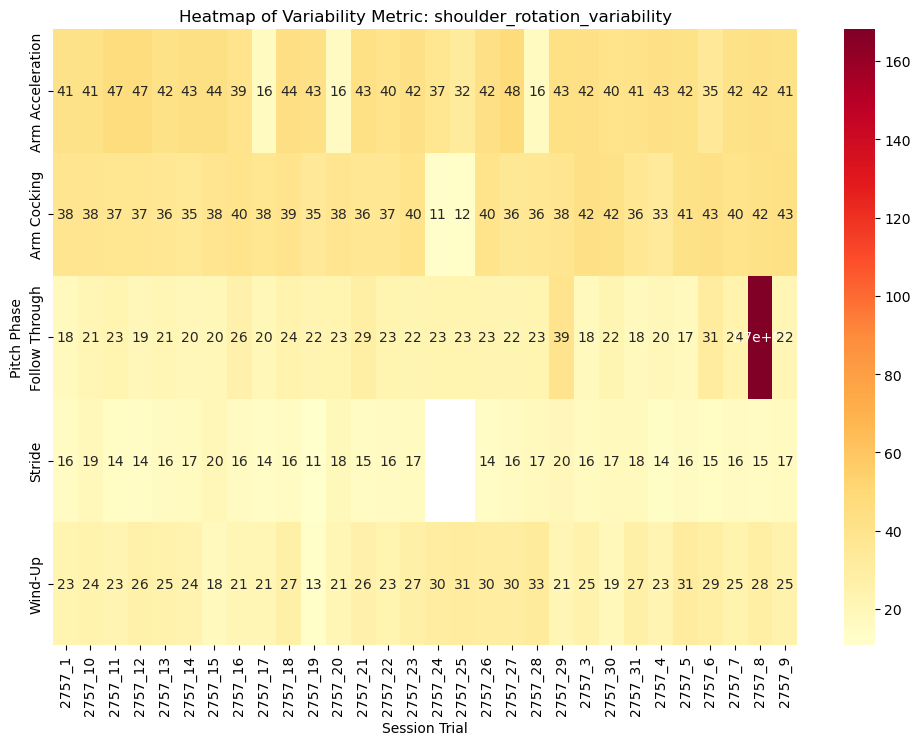

INFO:__main__:Filtering variability timeseries for player: Josh Hejka
INFO:__main__:Filtered DataFrame shape for timeseries: (148, 54)


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import logging

# Ensure logger is defined
logger = logging.getLogger(__name__)

def create_player_profile_dashboard(df):
    """
    Create a comprehensive player profile showing biomechanical metrics
    grouped by pitch type and session.
    """
    # Group by player name and pitch type, and aggregate selected metrics.
    profile = df.groupby(['player_name', 'pitch_type']).agg({
        'pitch_speed_mph': ['mean', 'std'],
        'max_shoulder_internal_rotational_velo': ['mean', 'std'],
        'max_elbow_varus_moment': ['mean', 'std']
        # Add other relevant metrics as needed.
    }).reset_index()
    return profile

def create_pitch_comparison_visualization(df):
    """
    Compare biomechanical metrics across different pitch types using violin plots.
    """
    fig = px.violin(
        df, 
        x="pitch_type", 
        y="max_shoulder_internal_rotational_velo",
        color="pitch_type",
        box=True, 
        points="all",
        title="Distribution of Max Shoulder Internal Rotational Velocity by Pitch Type"
    )
    return fig

def plot_variability_heatmap(df, player_name=None):
    """
    Create a heatmap to visualize variability metrics across different pitch phases.
    
    Parameters:
    - df: DataFrame containing biomechanical metrics.
    - player_name: Optional; if provided, filters the DataFrame to only include data for that player.
    
    This function selects the first variability metric found (e.g., elbow_flexion_variability)
    and creates a pivot table with pitch phases as rows and session_trial as columns.
    """
    # Filter the DataFrame by player if a name is provided
    if player_name is not None:
        df = df[df['player_name'] == player_name]
        logger.info(f"Filtering variability heatmap for player: {player_name}")
    
    logger.info(f"Filtered DataFrame shape: {df.shape}")
    if df.empty:
        logger.warning("Filtered DataFrame is empty. No data available to plot heatmap.")
        return

    # Select only the columns with 'variability' in their name
    variability_columns = [col for col in df.columns if 'variability' in col.lower()]
    if not variability_columns:
        logger.warning("No variability columns found for heatmap.")
        return

    # Create a pivot table: rows as pitch_phase, columns as session_trial for the first variability metric.
    pivot_table = df.pivot(index='pitch_phase', columns='session_trial', values=variability_columns[0])
    logger.info(f"Pivot table shape: {pivot_table.shape}")
    if pivot_table.empty:
        logger.warning("Pivot table is empty for the given player. No data to plot.")
        return

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, cmap='YlOrRd', annot=True)
    plt.title("Heatmap of Variability Metric: " + variability_columns[0])
    plt.xlabel("Session Trial")
    plt.ylabel("Pitch Phase")
    plt.show()

def plot_variability_timeseries(df, player_name=None):
    """
    Create a time series plot showing selected variability metrics across pitch phases.
    
    Parameters:
    - df: DataFrame containing biomechanical metrics.
    - player_name: Optional; if provided, filters the DataFrame to only include data for that player.
    
    The plot includes elbow_flexion_variability, shoulder_rotation_variability,
    and torso_rotation_variability across the pitch phases.
    """
    # Filter the DataFrame by player if a name is provided
    if player_name is not None:
        df = df[df['player_name'] == player_name]
        logger.info(f"Filtering variability timeseries for player: {player_name}")
    
    logger.info(f"Filtered DataFrame shape for timeseries: {df.shape}")
    if df.empty:
        logger.warning("Filtered DataFrame is empty. No data available to plot timeseries.")
        return

    fig = px.line(
        df, 
        x='pitch_phase', 
        y=['elbow_flexion_variability', 'shoulder_rotation_variability', 'torso_rotation_variability'],
        title='Movement Variability Across Pitch Phases'
    )
    fig.update_layout(xaxis_title="Pitch Phase", yaxis_title="Variability Metric Value")
    fig.show()

# ----------------- Testing Section -----------------

if __name__ == "__main__": 
    # Replace 'final_metrics' with your actual DataFrame variable if needed.
    # For example, final_metrics = run_final_query() should have been run before.
    
    # Print the list of columns to verify the enriched dataset
    print("Columns in final_metrics:")
    print(final_metrics.columns.tolist())
    # Print unique player names
    print("\nUnique players in dataset:")
    print(final_metrics['player_name'].unique())
    print("\nUnique dates in dataset:")
    print(final_metrics['session_date'].unique())

    # Test the variability heatmap for a specific player (e.g., 'Josh Hejka')
    test_player = 'Josh Hejka'  # Change this to a name that exists in your data if needed.
    plot_variability_heatmap(final_metrics, player_name=test_player)

    # Test the variability timeseries for the same player
    plot_variability_timeseries(final_metrics, player_name=test_player)


In [24]:
import pandas as pd
import numpy as np

def summarize_emg_data(emg_df):
    """
    Summarize the EMG data by computing mean, std, min, max, and variance for each numeric column,
    grouped by a datetime key (floored to the minute based on the 'Date/Time' column).
    
    The column 'ThrowingMotion' is converted to a categorical and aggregated by taking its mode.
    
    Parameters:
      emg_df: DataFrame containing EMG data. Must include a 'Date/Time' column.
      
    Returns:
      summary_df: DataFrame with a 'datetime_key' column and aggregated statistics for numeric columns,
                  and the categorical 'ThrowingMotion' column.
    """
    # Convert "Date/Time" to datetime and floor to the minute.
    emg_df['datetime_key'] = pd.to_datetime(emg_df['Date/Time']).dt.floor('min')
    
    # Convert ThrowingMotion to a categorical type so it won't be treated as numeric.
    if 'ThrowingMotion' in emg_df.columns:
        emg_df['ThrowingMotion'] = emg_df['ThrowingMotion'].astype('category')
    
    # Get numeric columns (excluding ThrowingMotion if it was numeric)
    numeric_cols = emg_df.select_dtypes(include=[np.number]).columns.tolist()
    if 'ThrowingMotion' in numeric_cols:
        numeric_cols.remove('ThrowingMotion')
    
    # List of categorical columns we want to preserve – in this case, ThrowingMotion.
    cat_cols = []
    if 'ThrowingMotion' in emg_df.columns:
        cat_cols.append('ThrowingMotion')
    
    # Define aggregation functions for numeric columns.
    agg_funcs = ['mean', 'std', 'min', 'max', 'var']
    
    # Compute numeric summary grouped by datetime_key.
    numeric_summary = (
        emg_df.groupby('datetime_key')[numeric_cols]
              .agg(agg_funcs)
              .reset_index()
    )
    
    # Flatten the multi-level column names for the numeric summary.
    numeric_summary.columns = (
        ['datetime_key'] +
        [f"{col}_{stat}" for col in numeric_cols for stat in agg_funcs]
    )
    
    # For the categorical columns, we take the mode (most frequent value) for each group.
    # If there is more than one mode, we select the first one.
    cat_summary = (
        emg_df.groupby('datetime_key')[cat_cols]
              .agg(lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0])
              .reset_index()
    )
    
    # Merge the numeric and categorical summaries on datetime_key.
    summary_df = pd.merge(numeric_summary, cat_summary, on='datetime_key', how='left')
    
    return summary_df

def join_emg_with_biomech(summarized_bio, summarized_emg):
    """
    Joins the summarized EMG data with the summarized biomechanical profile using a common datetime key.
    
    The biomechanical profile is assumed to have a 'session_date' (as a date) and 'trial_time' (as a timedelta).
    These are combined and floored to the minute to form the 'datetime_key'.
    
    Parameters:
      summarized_bio: DataFrame containing the biomechanical metrics.
                      It must have columns 'session_date' (as a date) and 'trial_time' (as a timedelta).
      summarized_emg: DataFrame containing the summarized EMG data with a 'datetime_key' column.
                      
    Returns:
      merged_df: The merged DataFrame with summarized EMG data joined to the biomechanical profile.
    """
    # Ensure session_date is in datetime format.
    summarized_bio['session_date'] = pd.to_datetime(summarized_bio['session_date'])
    
    # Create the datetime_key by adding trial_time (a timedelta) to session_date and flooring to the minute.
    summarized_bio['datetime_key'] = (summarized_bio['session_date'] + summarized_bio['trial_time']).dt.floor('min')
    
    # --- Debug: Print unique keys to verify common values ---
    unique_bio_keys = summarized_bio['datetime_key'].unique()
    unique_emg_keys = summarized_emg['datetime_key'].unique()
    print("Unique datetime_key in summarized_bio:")
    print(unique_bio_keys)
    print("\nUnique datetime_key in summarized_emg:")
    print(unique_emg_keys)
    
    common_keys = set(unique_bio_keys).intersection(set(unique_emg_keys))
    print("\nNumber of common datetime keys:", len(common_keys))
    if common_keys:
        print("Common datetime keys:")
        print(common_keys)
    else:
        print("No common datetime keys found.")
    
    # Perform an inner join on the datetime_key.
    merged_df = pd.merge(summarized_bio, summarized_emg, on='datetime_key', how='inner')
    
    return merged_df

# ----------------- Usage Example -----------------

# Load your summarized biomechanical profile
summarized_bio = pd.read_parquet('../../data/processed/ml_datasets/summarized/final_summarized_biomechanical_profile.parquet')
print("\nSummarized Biomechanical Profile Info:")
print("Unique session_date:", summarized_bio['session_date'].unique())
print("Unique trial_time:", summarized_bio['trial_time'].unique())

# Load your raw EMG pitch data
emg_pitch_data = pd.read_parquet('../../data/processed/emg_pitch_data_processed.parquet')
print("\nEMG Pitch Data Info:")
print("Unique Date/Time:", emg_pitch_data['Date/Time'].unique())

# Summarize the EMG data (compute aggregated statistics for each numeric column and mode for ThrowingMotion)
summarized_emg = summarize_emg_data(emg_pitch_data)

# Join the summarized EMG data with the biomechanical profile using the common datetime key.
merged_data = join_emg_with_biomech(summarized_bio, summarized_emg)

# Display the result.
print("\nMerged DataFrame Columns:")
print(merged_data.columns.tolist())
print("\nMerged DataFrame Head:")
print(merged_data.head())



Summarized Biomechanical Profile Info:
Unique session_date: [datetime.date(2025, 2, 14)]
Unique trial_time: <TimedeltaArray>
['0 days 09:50:16', '0 days 09:50:29', '0 days 09:50:53', '0 days 09:51:08',
 '0 days 09:51:25', '0 days 09:51:39', '0 days 09:51:52', '0 days 10:25:34',
 '0 days 10:25:54', '0 days 10:26:15',
 ...
 '0 days 17:34:36', '0 days 17:34:54', '0 days 17:51:55', '0 days 17:52:14',
 '0 days 17:52:29', '0 days 17:52:45', '0 days 17:53:35', '0 days 17:53:58',
 '0 days 17:55:37', '0 days 17:55:56']
Length: 110, dtype: timedelta64[ns]

EMG Pitch Data Info:
Unique Date/Time: ['2/14/2025 11:42:22 AM']
Unique datetime_key in summarized_bio:
<DatetimeArray>
['2025-02-14 09:50:00', '2025-02-14 09:51:00', '2025-02-14 10:25:00',
 '2025-02-14 10:26:00', '2025-02-14 10:27:00', '2025-02-14 10:47:00',
 '2025-02-14 10:54:00', '2025-02-14 10:55:00', '2025-02-14 10:59:00',
 '2025-02-14 11:00:00', '2025-02-14 11:10:00', '2025-02-14 11:11:00',
 '2025-02-14 11:12:00', '2025-02-14 11:13:00',